In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
x_train = np.load('Train_3D_128_FOV_norm_data.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))
vol_shape = x_train.shape[1:]
print('train vol_shape:', vol_shape)
print('train shape:', x_train.shape)

train vol_shape: (128, 128, 128)
train shape: (57, 128, 128, 128)


In [5]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
inshape = (*x_train.shape[1:], unet_input_features)

# configure unet features 
# nb_features = [
#     [16, 32, 32, 32],
#     [32, 32, 32, 32, 32, 16, 16]
# ]

nb_features = [
    [32, 64, 64, 64],
    [64, 64, 64, 64, 32, 16, 16]
]

# nb_features = [
#     [64, 128, 256, 512],
#     [512, 512, 256, 128, 64, 32, 16]
# ]
model3D = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)
model3D.to(device)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[64, 64, 64]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


VxmDense(
  (unet_model): Unet(
    (encoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (2-3): 2 x ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
    )
    (decoder): ModuleList(
      (0): ModuleList(
        (0): ConvBlock(
          (main): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (activation): LeakyReLU(negative_slope=0.2)
        )
      )
      (1-3): 3 x ModuleList(
        (0): ConvBlock(
  

In [6]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [7]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 128, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 128, 128])
Zero Gradient Shape: (2, 128, 128, 128, 3)


In [8]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

In [9]:
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

In [10]:
from tqdm.notebook import tqdm

epochs = 400
losses = []
mses = []
grads = []



# model3D.load_state_dict(torch.load('model_VXM_3D_weights_SGDm.pth', map_location=device)
for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(16,16,16), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(16,16,16), mode='trilinear', align_corners=False)
    moving_images = torch.nn.functional.interpolate(moving_images, size=(128, 128, 128), mode='nearest')
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(128, 128, 128), mode='nearest')
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D(moving_images, fixed_images)
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D.state_dict(), 'model_VXM_3D_weights_V222_1_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Mses: {mses}, Grad: {grad}")

  0%|          | 0/400 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_17988\2017604655.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_17988\2017604655.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/400, Loss: 0.0225, Mses: [0.022446472197771072], Grad: 0.0012232986046001315
Epoch 2/400, Loss: 0.0278, Mses: [0.022446472197771072, 0.027822384610772133], Grad: 0.0018836170202121139
Epoch 3/400, Loss: 0.0267, Mses: [0.022446472197771072, 0.027822384610772133, 0.026648979634046555], Grad: 0.0011050121393054724
Epoch 4/400, Loss: 0.0288, Mses: [0.022446472197771072, 0.027822384610772133, 0.026648979634046555, 0.02877565287053585], Grad: 0.001990767428651452
Epoch 5/400, Loss: 0.0241, Mses: [0.022446472197771072, 0.027822384610772133, 0.026648979634046555, 0.02877565287053585, 0.024081546813249588], Grad: 0.0017095047514885664
Epoch 6/400, Loss: 0.0206, Mses: [0.022446472197771072, 0.027822384610772133, 0.026648979634046555, 0.02877565287053585, 0.024081546813249588, 0.020580101758241653], Grad: 0.0013622650876641273
Epoch 7/400, Loss: 0.0289, Mses: [0.022446472197771072, 0.027822384610772133, 0.026648979634046555, 0.02877565287053585, 0.024081546813249588, 0.020580101758241653,

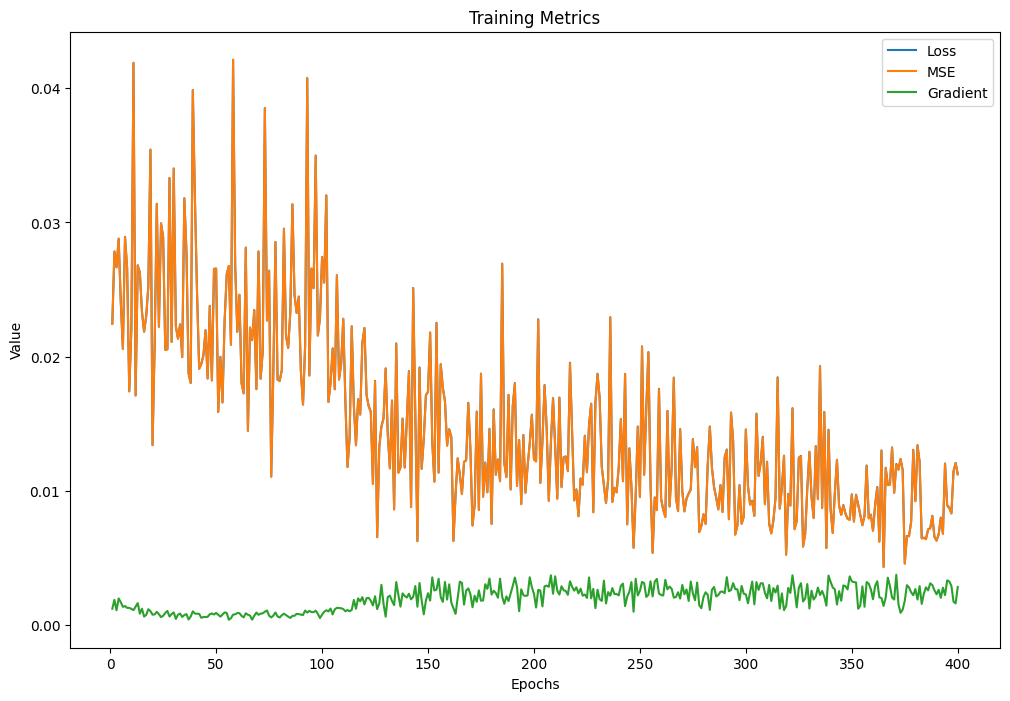

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [12]:
optimizer = optim.Adam(model3D.parameters(), lr=1e-5)

In [13]:
from tqdm.notebook import tqdm

epochs = 400
losses = []
mses = []
grads = []



model3D.load_state_dict(torch.load('model_VXM_3D_weights_V222_1_omomi.pth', map_location=device))
for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(32,32,32), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(32,32,32), mode='trilinear', align_corners=False)
    moving_images = torch.nn.functional.interpolate(moving_images, size=(128, 128, 128), mode='nearest')
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(128, 128, 128), mode='nearest')
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D(moving_images, fixed_images)
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D.state_dict(), 'model_VXM_3D_weights_V222_2_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Mses: {mses}, Grad: {grad}")

  0%|          | 0/400 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_17988\4147085881.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_17988\4147085881.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/400, Loss: 0.0065, Mses: [0.0065041095949709415], Grad: 0.001962807960808277
Epoch 2/400, Loss: 0.0079, Mses: [0.0065041095949709415, 0.00783124752342701], Grad: 0.002770274644717574
Epoch 3/400, Loss: 0.0083, Mses: [0.0065041095949709415, 0.00783124752342701, 0.008268759585916996], Grad: 0.002380982507020235
Epoch 4/400, Loss: 0.0160, Mses: [0.0065041095949709415, 0.00783124752342701, 0.008268759585916996, 0.016026068478822708], Grad: 0.001203062362037599
Epoch 5/400, Loss: 0.0086, Mses: [0.0065041095949709415, 0.00783124752342701, 0.008268759585916996, 0.016026068478822708, 0.008615834638476372], Grad: 0.00270478124730289
Epoch 6/400, Loss: 0.0057, Mses: [0.0065041095949709415, 0.00783124752342701, 0.008268759585916996, 0.016026068478822708, 0.008615834638476372, 0.00568798603489995], Grad: 0.001730248099192977
Epoch 7/400, Loss: 0.0099, Mses: [0.0065041095949709415, 0.00783124752342701, 0.008268759585916996, 0.016026068478822708, 0.008615834638476372, 0.00568798603489995, 0.

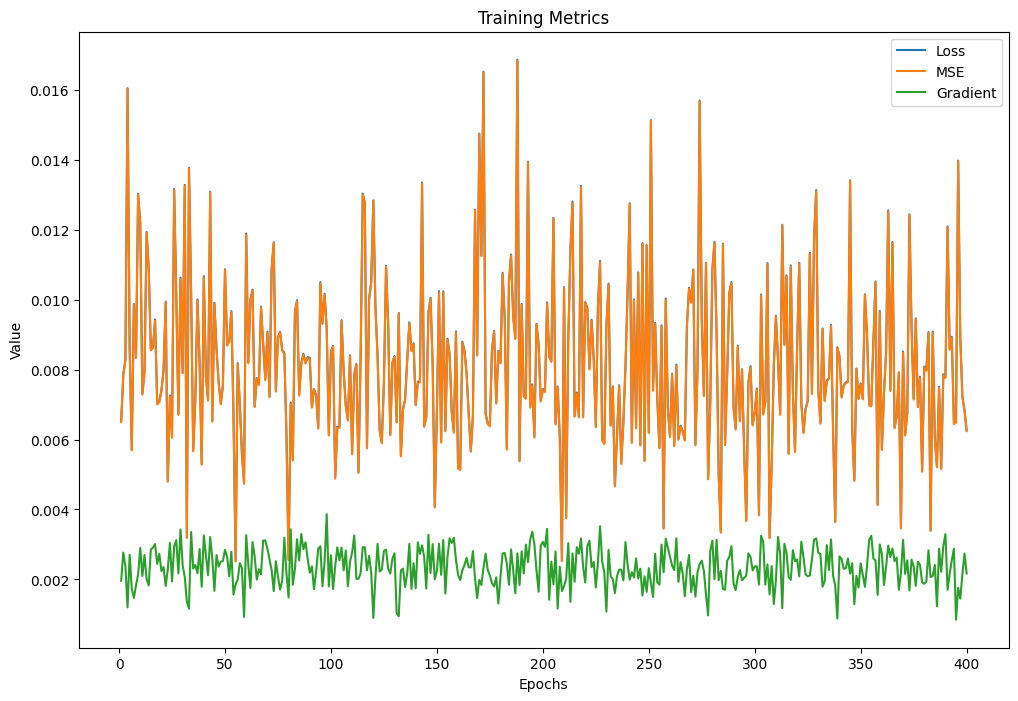

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [15]:
optimizer = optim.Adam(model3D.parameters(), lr=1e-6)

In [16]:
from tqdm.notebook import tqdm

epochs = 400
losses = []
mses = []
grads = []



model3D.load_state_dict(torch.load('model_VXM_3D_weights_V222_2_omomi.pth', map_location=device))
for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(64,64,64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64,64,64), mode='trilinear', align_corners=False)
    moving_images = torch.nn.functional.interpolate(moving_images, size=(128, 128, 128), mode='nearest')
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(128, 128, 128), mode='nearest')
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D(moving_images, fixed_images)
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D.state_dict(), 'model_VXM_3D_weights_V222_3_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Mses: {mses}, Grad: {grad}")

  0%|          | 0/400 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_17988\1566864349.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_17988\1566864349.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/400, Loss: 0.0069, Mses: [0.006905457936227322], Grad: 0.001682147616520524
Epoch 2/400, Loss: 0.0100, Mses: [0.006905457936227322, 0.010029206052422523], Grad: 0.0017339750193059444
Epoch 3/400, Loss: 0.0063, Mses: [0.006905457936227322, 0.010029206052422523, 0.006236257031559944], Grad: 0.0027464847080409527
Epoch 4/400, Loss: 0.0057, Mses: [0.006905457936227322, 0.010029206052422523, 0.006236257031559944, 0.005663253366947174], Grad: 0.002389639150351286
Epoch 5/400, Loss: 0.0081, Mses: [0.006905457936227322, 0.010029206052422523, 0.006236257031559944, 0.005663253366947174, 0.008067772723734379], Grad: 0.002606480848044157
Epoch 6/400, Loss: 0.0061, Mses: [0.006905457936227322, 0.010029206052422523, 0.006236257031559944, 0.005663253366947174, 0.008067772723734379, 0.00605213874951005], Grad: 0.0017327163368463516
Epoch 7/400, Loss: 0.0068, Mses: [0.006905457936227322, 0.010029206052422523, 0.006236257031559944, 0.005663253366947174, 0.008067772723734379, 0.00605213874951005,

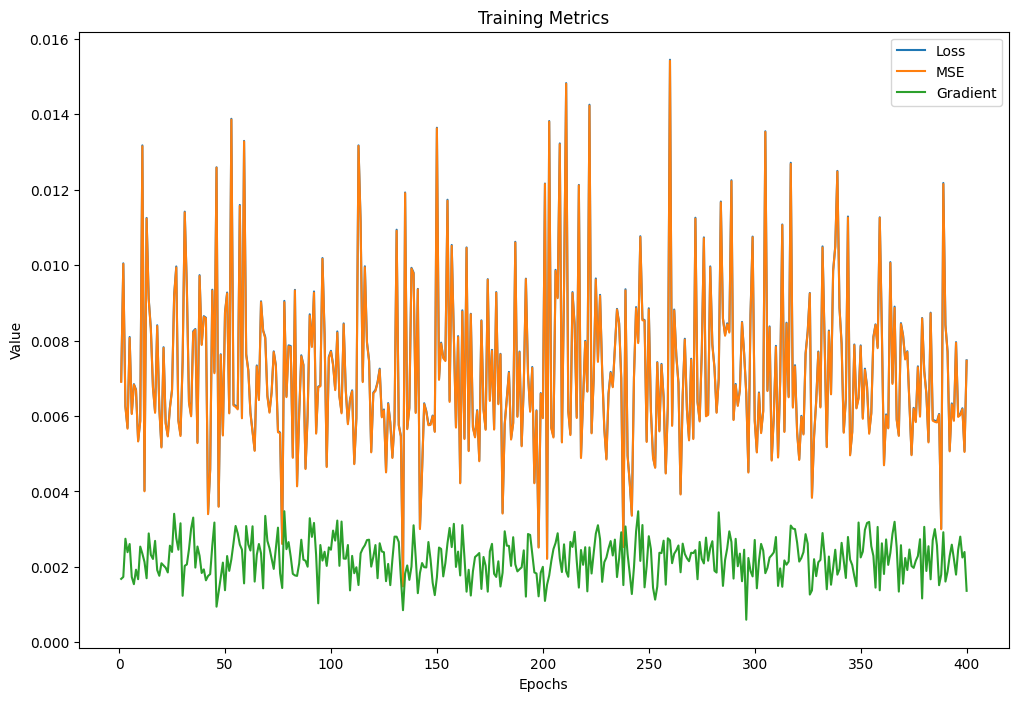

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [18]:
optimizer = optim.Adam(model3D.parameters(), lr=1e-7)

In [19]:
from tqdm.notebook import tqdm

epochs = 400
losses = []
mses = []
grads = []



model3D.load_state_dict(torch.load('model_VXM_3D_weights_V222_3_omomi.pth', map_location=device))
for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D(moving_images, fixed_images)
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D.state_dict(), 'model_VXM_3D_weights_V222_4_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Mses: {mses}, Grad: {grad}")

  0%|          | 0/400 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_17988\415119297.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_17988\415119297.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/400, Loss: 0.0045, Mses: [0.004520953632891178], Grad: 0.0018921077717095613
Epoch 2/400, Loss: 0.0071, Mses: [0.004520953632891178, 0.007104872725903988], Grad: 0.0027997451834380627
Epoch 3/400, Loss: 0.0068, Mses: [0.004520953632891178, 0.007104872725903988, 0.0068132309243083], Grad: 0.0034981989301741123
Epoch 4/400, Loss: 0.0077, Mses: [0.004520953632891178, 0.007104872725903988, 0.0068132309243083, 0.007632240653038025], Grad: 0.00240202690474689
Epoch 5/400, Loss: 0.0049, Mses: [0.004520953632891178, 0.007104872725903988, 0.0068132309243083, 0.007632240653038025, 0.0049245283007621765], Grad: 0.002397195203229785
Epoch 6/400, Loss: 0.0093, Mses: [0.004520953632891178, 0.007104872725903988, 0.0068132309243083, 0.007632240653038025, 0.0049245283007621765, 0.009307445026934147], Grad: 0.0033307536505162716
Epoch 7/400, Loss: 0.0057, Mses: [0.004520953632891178, 0.007104872725903988, 0.0068132309243083, 0.007632240653038025, 0.0049245283007621765, 0.009307445026934147, 0.00

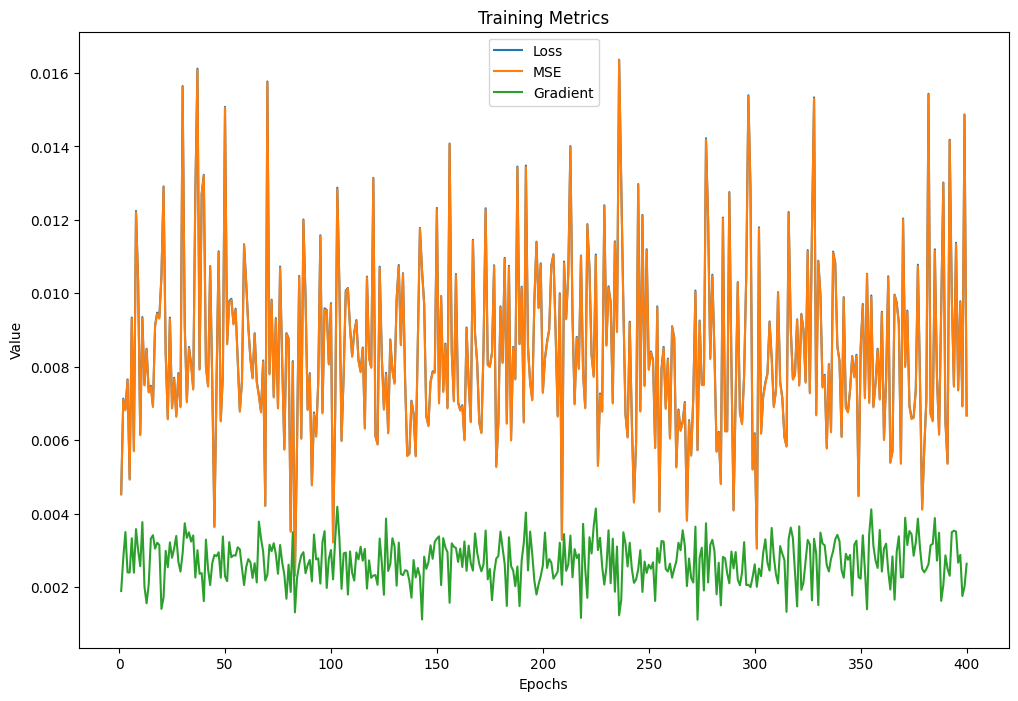

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [21]:
CT1 = np.load('No6_CT1.npz')['Val']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2.npz')['Val']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

CT1_shape: (1, 128, 128, 128)
CT2_shape: (1, 128, 128, 128)


In [22]:
x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

torch.Size([2, 1, 128, 128, 128])
torch.Size([2, 1, 128, 128, 128])


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 学習済みモデルが既にある場合
model3D.load_state_dict(torch.load('model_VXM_3D_weights_V222_2_omomi.pth', map_location=device))


# 検証データを使って予測を行う
model3D.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(64,64,64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64,64,64), mode='trilinear', align_corners=False)
    moving_images = torch.nn.functional.interpolate(moving_images, size=(128, 128, 128), mode='nearest')
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(128, 128, 128), mode='nearest')
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

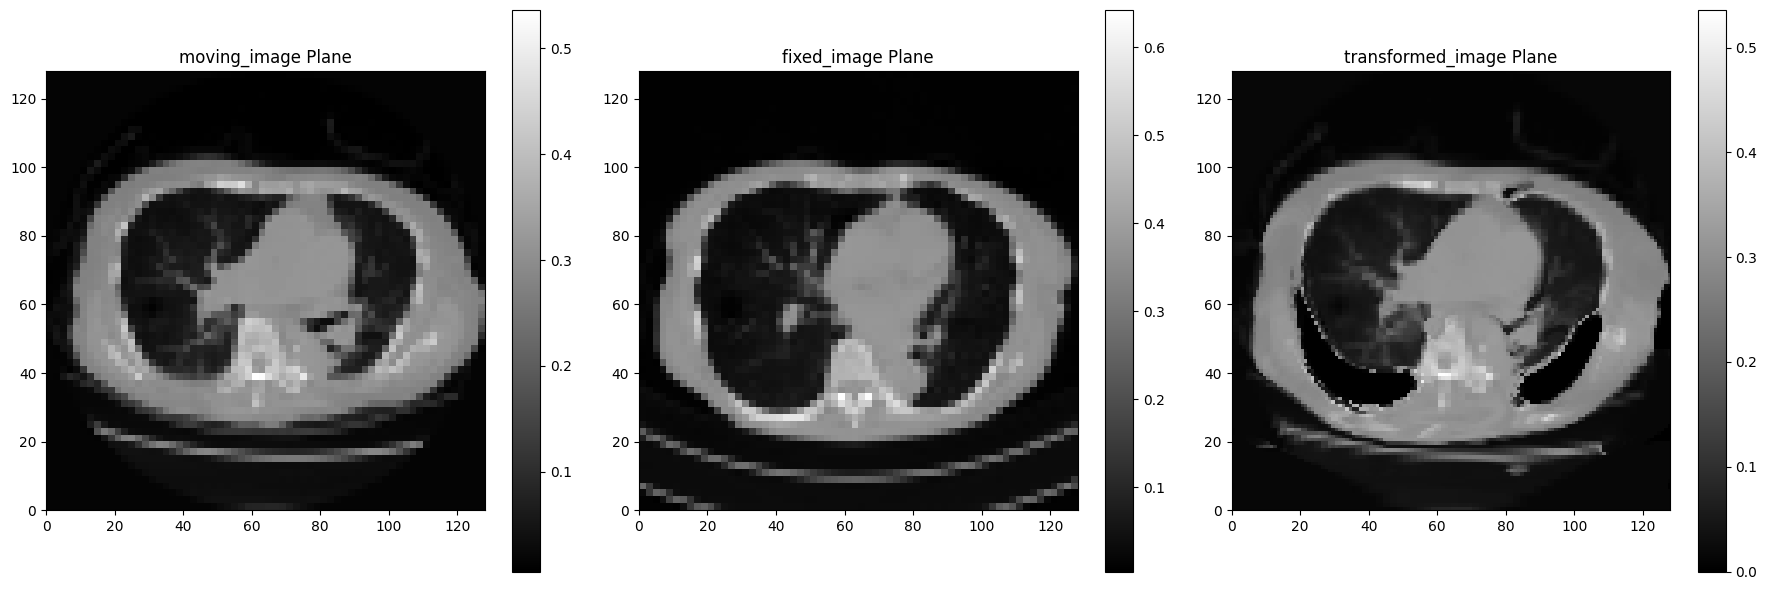

In [37]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする


# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, 64, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, 64, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, 64, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [38]:
imsave('source_64-128V222.tif', A)
imsave('target_64-128V222.tif', B)
imsave('moved_64-128_2V222.tif', C)

C:\Users\user\AppData\Local\Temp\ipykernel_17988\2887164936.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('source_64-128V222.tif', A)
C:\Users\user\AppData\Local\Temp\ipykernel_17988\2887164936.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('target_64-128V222.tif', B)
C:\Users\user\AppData\Local\Temp\ipykernel_17988\2887164936.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_64-128_2V222.tif', C)


In [25]:
def dice_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    return 2.0 * intersection.sum() / (img1.sum() + img2.sum())

def jaccard_coefficient(img1, img2):
    intersection = np.logical_and(img1, img2)
    union = np.logical_or(img1, img2)
    return intersection.sum() / union.sum()

# 画像を2値化（任意のしきい値でしきい値処理を行う）
threshold = 0.3  # しきい値（任意の値を設定してください）
fixed_image_bin = (fixed_image > threshold).astype(int)
transformed_image_bin = (transformed_image > threshold).astype(int)

# Dice係数とJaccard係数を計算
dice = dice_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Dice係数: {dice}")
jaccard = jaccard_coefficient(fixed_image_bin, transformed_image_bin)
print(f"Jaccard係数: {jaccard}")

Dice係数: 0.7546292690912154
Jaccard係数: 0.6059474904637752
